In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt 
import seaborn as sns
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [9]:
# Load data & model
print("Loading data...")
X_train = np.load("../data/processed/X_train.npy")
X_test = np.load("../data/processed/X_test.npy")
y_test = np.load("../data/processed/y_test.npy", allow_pickle=True)

print("Loading model...")
autoencoder = load_model("../models/autoencoder.keras")

print(f"Test data shape: {X_test.shape}")
print("Ready for evaluation.")

Loading data...
Loading model...
Test data shape: (1012266, 21)
Ready for evaluation.


In [10]:
# calculating reconstruction error
print("Running Analysis..")
reconstructions = autoencoder.predict(X_test, verbose=1)

# calculating MSE
mse = np.mean(np.power(X_test - reconstructions, 2), axis=1)

print(f"Calculated {len(mse)} threat scores.")
print(f"Average Error: {np.mean(mse):.4f}")
print(f"Min Error: {np.min(mse):.4f}")
print(f"Max Error: {np.max(mse):.4f}")



Running Analysis..
31634/31634 ━━━━━━━━━━━━━━━━━━━━ 5s 162us/step
Calculated 1012266 threat scores.
Average Error: 0.3376
Min Error: 0.0000
Max Error: 303.7739


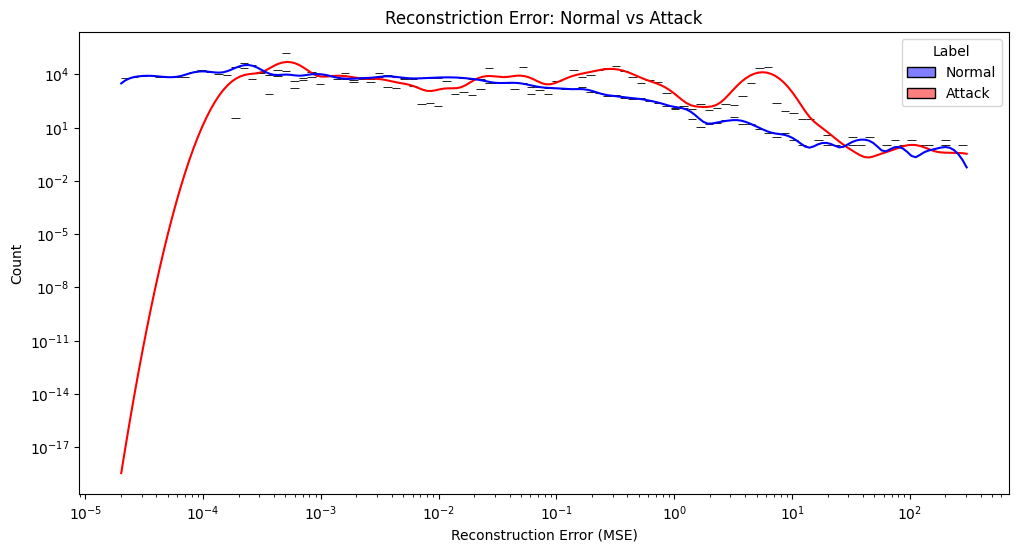

In [11]:
# Visualization
clean_labels = y_test

error_df = pd.DataFrame({'reconstruction_error': mse, 'true_class': clean_labels})

error_df['true_class'] = error_df['true_class'].astype(str).str.strip()

error_df['Label'] = error_df['true_class'].apply(lambda x: 'Normal' if 'BENIGN' in x else 'Attack')

plt.figure(figsize=(12,6))
sns.histplot(
            data=error_df,
            x='reconstruction_error',
            hue='Label',
            bins=100,
            kde=True,
            palette={'Normal': 'blue', 'Attack': 'red'},
            log_scale=(True, True)
)  

plt.title("Reconstriction Error: Normal vs Attack")
plt.xlabel("Reconstruction Error (MSE)")
plt.ylabel("Count")
plt.show()


In [19]:
# # Calculating threshold

# # determining threshold
# from tabnanny import verbose

# from torch import threshold


# print("Calculating threshold using training data...")
# train_reconstructions = autoencoder.predict(X_train, verbose=0)
# train_loss = np.mean(np.square(X_train - train_reconstructions), axis=1)

# # Threshold = Mean + 2 * Std_Dev 
# threshold = np.mean(train_loss) + 2 * np.std(train_loss)
# print(f"Threshold set as: {threshold:.4f}")

threshold = 0.1

In [20]:
# Calculating metrices 

# if error > threshold -> Attack(1) else Normal(0)
y_pred = [1 if e > threshold else 0 for e in mse]

y_true = [0 if label == 'BENIGN' else 1 for label in y_test]

print("------REPORT CARD------")
print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred):.4f}")
print(f"Recall: {recall_score(y_true, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_true, y_pred):.4f}")


------REPORT CARD------
Accuracy: 0.6257
Precision: 0.9448
Recall: 0.3404
F1 Score: 0.5005


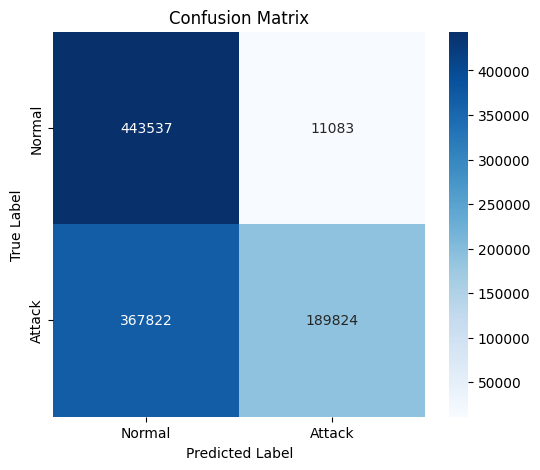

In [14]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

/var/folders/n3/lsbnbfr506q92gbtjsmwsxs80000gn/T/ipykernel_38805/3772369331.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=detection_rates.index, y=detection_rates.values, palette='magma')


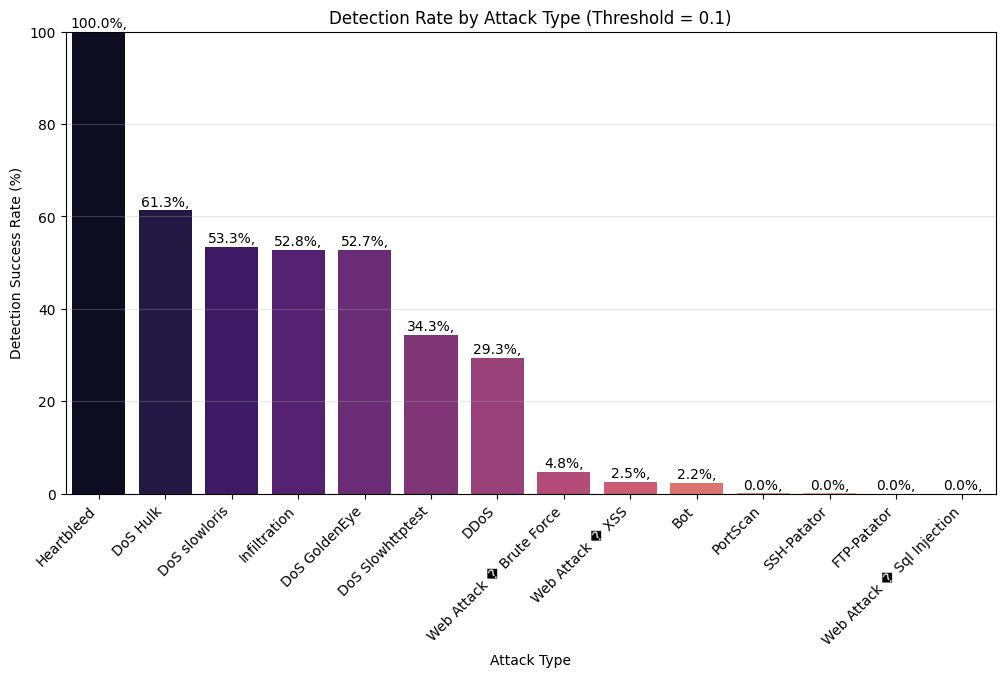

In [16]:
# Attack detection breakdown

# creating DataFrame with raw labels
from sympy import rotations


raw_labels = [str(label).strip() for label in y_test]
breakdown_df = pd.DataFrame({
    'Attack_Type': raw_labels,
    'Reconstruction_Error': mse,
    'Predicted_Status': ['Detected' if p == 1 else 'Missed' for p in y_pred]
})

# Takking only the attacks
attack_df = breakdown_df[breakdown_df['Attack_Type'] != 'BENIGN']

# detection rate per attack type
detection_stats = attack_df.groupby('Attack_Type')['Predicted_Status'].value_counts(normalize=True).unstack().fillna(0)

if "Detected" not in detection_stats.columns:
    detection_stats['Detected'] = 0.0

detection_rates = detection_stats['Detected'] * 100
detection_rates = detection_rates.sort_values(ascending=False)

# Visualize
plt.figure(figsize=(12, 6))
sns.barplot(x=detection_rates.index, y=detection_rates.values, palette='magma')
plt.title("Detection Rate by Attack Type (Threshold = 0.1)")
plt.ylabel("Detection Success Rate (%)")
plt.xlabel("Attack Type")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3)

for i, v in enumerate(detection_rates.values):
    plt.text(i, v+1, f"{v:.1f}%,", ha='center', fontsize=10)

plt.show()
